## Week 1 · Exploratory Data Analysis (EDA)  🔎

Before training any model, it is good practice to **look at the data first**. Exploratory Data Analysis (EDA) is the step of summarising and visualising a dataset to understand its main characteristics: how much data there is, how it is distributed, and whether it hides problems such as class imbalance, outliers, mislabelled samples or inconsistent recording conditions.

With EDA, you will be able to make *informed* decisions that come next: how to clean the data, which augmentations make sense, and what performance to expect. The better you know your data, the fewer surprises during training.

Ensure your dataset has one folder per sequence, each with an `images/` and a `labels/` subfolder:

```
dataset/
└── Video_1/
    ├── images/   # frames (.jpg)
    └── labels/   # bounding boxes (.xml, Pascal VOC)
```

### Imports

In [1]:
import os
import numpy as np
from tqdm import tqdm
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

### Load the dataset

Point `PATH_DATA` to your dataset, then load every label into a nested dictionary `DATA[sequence][frame] = {'frame_path', 'bboxes'}`.

In [2]:
PATH_DATA = '../data_train'

In [3]:
def list_dir(path):
    """List a folder, skipping caches like __pycache__ and .ipynb_checkpoints."""
    return sorted(e for e in os.listdir(path) if not e.startswith('.') and e != '__pycache__')


def load_labels(xml_path):
    """Read a Pascal VOC .xml file, returning (frame_filename, list of [x_min, y_min, x_max, y_max])."""
    root = ET.parse(xml_path).getroot()
    frame_filename = root.find('filename').text
    bboxes = [[int(box.find(c).text) for c in ('xmin', 'ymin', 'xmax', 'ymax')]
              for box in root.iter('bndbox')]
    return frame_filename, bboxes


def load_data(path, sequences):
    """Load every sequence into data[sequence][frame] = {'frame_path', 'bboxes'}."""
    data = {}
    for seq in sequences:
        data[seq] = {}
        labels_dir = os.path.join(path, seq, 'labels')
        for label_file in list_dir(labels_dir):
            frame_filename, bboxes = load_labels(os.path.join(labels_dir, label_file))
            frame_path = os.path.join(path, seq, 'images', frame_filename)
            frame_name = os.path.splitext(label_file)[0]
            data[seq][frame_name] = {'frame_path': frame_path, 'bboxes': bboxes}
    return data

In [4]:
# Every subfolder of PATH_DATA is a sequence
SEQUENCES = [s for s in list_dir(PATH_DATA) if os.path.isdir(os.path.join(PATH_DATA, s))]
DATA = load_data(PATH_DATA, SEQUENCES)
print(f'Loaded {len(SEQUENCES)} sequences: {SEQUENCES}')

Loaded 5 sequences: ['RoboMaster-Aisle', 'RoboMaster-GTI', 'RoboMaster-Parking', 'RoboMaster-SoccerCourt', 'RoboMaster-Stairs']


### Show a frame

Each box is drawn as a coloured outline so it stands out without hiding the pixels underneath.

In [5]:
def show_frame(element, color='tab:green'):
    """Display a frame with its bounding boxes drawn on top."""
    ax = plt.gca()
    ax.imshow(plt.imread(element['frame_path']))
    ax.axis('off')
    for x_min, y_min, x_max, y_max in element['bboxes']:
        # Coloured outline, no fill
        ax.add_patch(Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                               linewidth=2, edgecolor=color, facecolor='none'))
    plt.show()

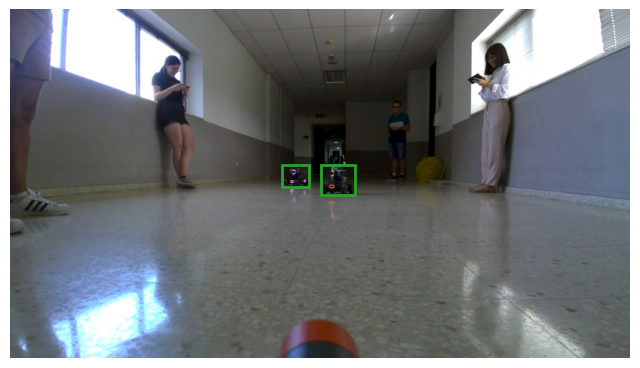

In [6]:
# Pick any frame (here, the first one of the first sequence)
sequence = SEQUENCES[0]
frame_name = list(DATA[sequence])[0]
plt.figure(figsize=(8, 5))
show_frame(DATA[sequence][frame_name])

### Frames and boxes per sequence

In [7]:
def bar_plot(counts, title, ylabel, color='tab:blue'):
    """Draw a bar chart from a {name: count} dict, widening with the number of bars."""
    plt.figure(figsize=(max(6, 1.2 * len(counts)), 4))
    bars = plt.bar(list(counts), list(counts.values()), color=color)
    # Labels inside the bars, in white, to avoid colliding with the title
    plt.bar_label(bars, label_type='center', color='white', fontweight='bold')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def plot_frames_per_sequence(data):
    """Bar chart of the number of frames per sequence."""
    counts = {seq: len(frames) for seq, frames in data.items()}
    bar_plot(counts, 'Frames per sequence', 'Number of frames')


def plot_boxes_per_sequence(data):
    """Bar chart of the number of bounding boxes per sequence."""
    counts = {seq: sum(len(f['bboxes']) for f in frames.values()) for seq, frames in data.items()}
    bar_plot(counts, 'Bounding boxes per sequence', 'Number of boxes')

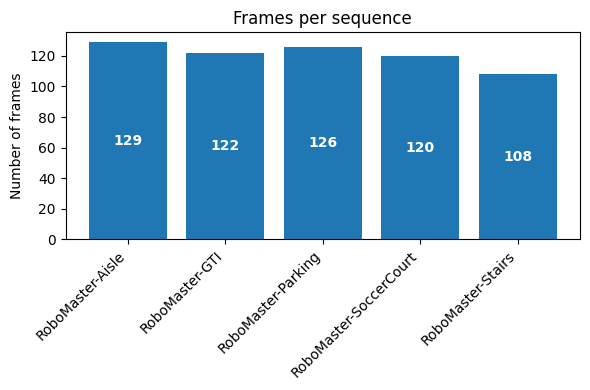

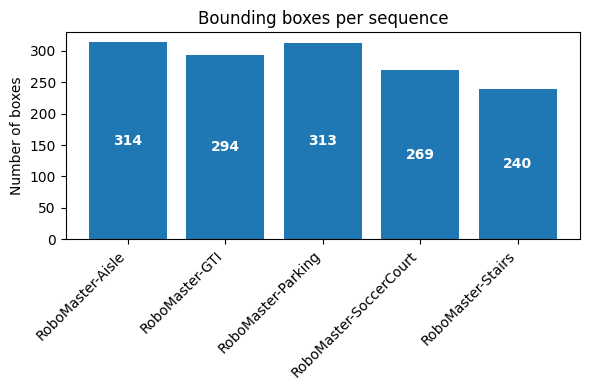

In [8]:
plot_frames_per_sequence(DATA)
plot_boxes_per_sequence(DATA)

### Bounding-box area distribution

Box areas (in kilopixels) tell you how big the objects appear: small boxes are far away, large boxes are close.

In [13]:
def subplot_grid(n, sharey=True):
    """Create a grid of n subplots (max 4 per row) and return (fig, flat axes for the n plots)."""
    ncols = min(n, 4)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharey=sharey, squeeze=False)
    axes = axes.ravel()
    for ax in axes[n:]:   # hide the empty cells of the last row
        ax.axis('off')
    return fig, axes[:n]


def box_areas(frames):
    """Return the area (in kilopixels) of every box in a sequence."""
    return [(x_max - x_min) * (y_max - y_min) / 1000
            for f in frames.values() for x_min, y_min, x_max, y_max in f['bboxes']]


def plot_area_distribution(data, bins=30):
    """Histogram of box areas, one subplot per sequence."""
    fig, axes = subplot_grid(len(data))
    fig.suptitle('Bounding-box area per sequence')
    for ax, (seq, frames) in zip(axes, data.items()):
        ax.hist(box_areas(frames), bins=bins, color='tab:blue')
        ax.set_title(seq)
        ax.set_xlabel('Area ($\mathrm{kpx}^2$)')
    axes[0].set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

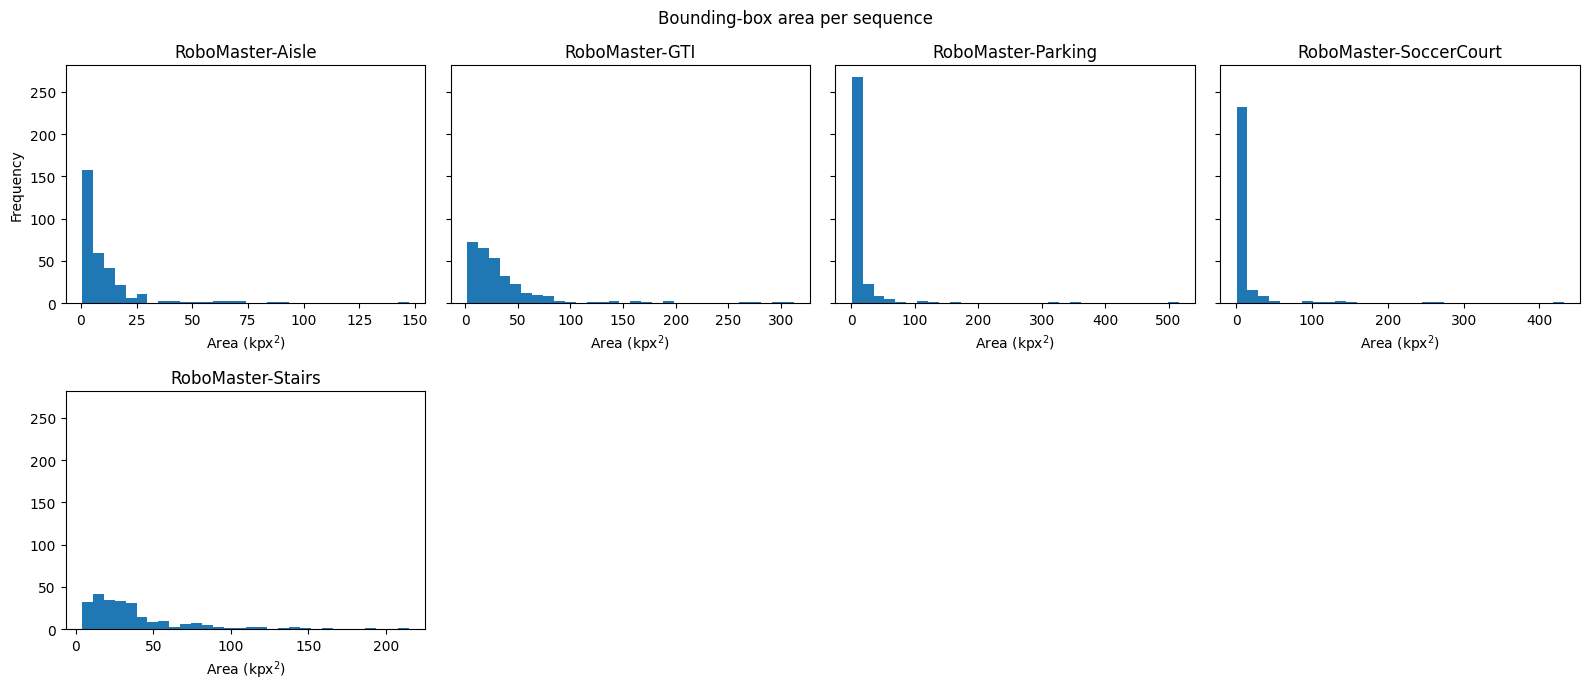

In [14]:
plot_area_distribution(DATA)

### RGB distribution

Average each frame to one (R, G, B) value and histogram it per channel. Different lighting between sequences shows up as shifted colour distributions.

In [11]:
def plot_rgb_distribution(data, bins=30):
    """Histogram of the mean R, G, B value per frame, one subplot per sequence."""
    fig, axes = subplot_grid(len(data))
    fig.suptitle('Mean RGB per frame')
    for ax, (seq, frames) in zip(axes, data.items()):
        # Average every frame down to a single (R, G, B) triplet
        means = np.array([plt.imread(f['frame_path']).mean(axis=(0, 1))
                          for f in tqdm(frames.values(), desc=seq)])
        for channel, color in enumerate(('red', 'green', 'blue')):
            ax.hist(means[:, channel], bins=bins, color=color, alpha=0.5, label=color)
        ax.set_title(seq)
        ax.set_xlabel('Mean pixel value')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    plt.tight_layout()
    plt.show()

RoboMaster-Stairs: 100%|██████████| 108/108 [00:01<00:00, 78.20it/s]


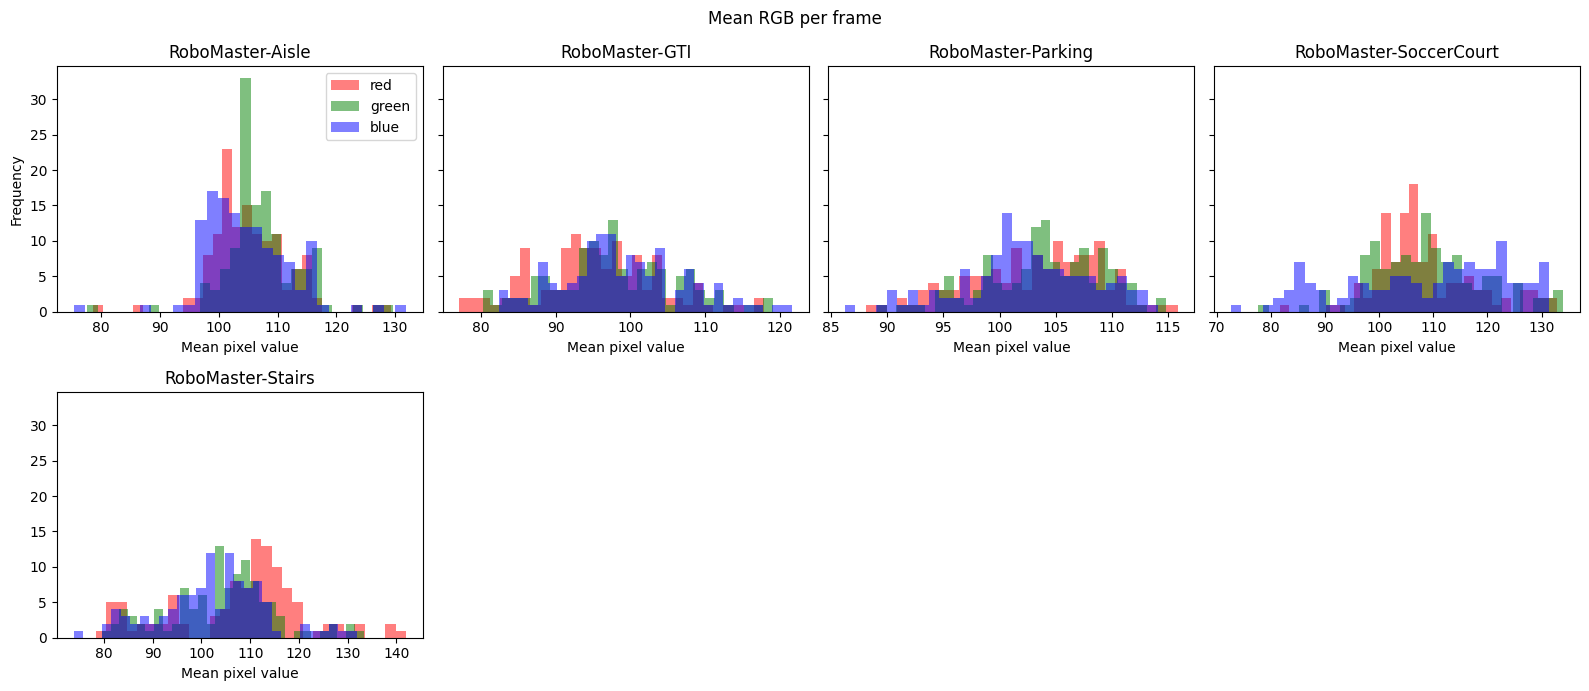

In [15]:
plot_rgb_distribution(DATA)